# ElasticNet Regression

**Context:** Combines the L1 (Lasso) and L2 (Ridge) penalties:

$$\text{Loss} = \text{MSE} + \alpha \left[ \frac{1-\rho}{2} \|\beta\|_2^2 + \rho \|\beta\|_1 \right]$$

where `alpha` controls overall regularization strength and `l1_ratio` (ρ) blends L1 vs L2.
Setting `l1_ratio=0` recovers Ridge; `l1_ratio=1` recovers Lasso.
The 2D grid search finds the best (alpha, l1_ratio) pair using validation OOS R².

**Pipeline:** Load data → year-based train/val/test split → standardize (train only)
→ 2D grid search on validation OOS R² → evaluate on test → long-short portfolio → save results.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- ElasticNet grid ---
    'ALPHAS':             [1e-4, 1e-3, 0.01, 0.1, 1.0],
    'L1_RATIOS':          [0.1, 0.3, 0.5, 0.7, 0.9],
    'MAX_ITER':           5000,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  ALPHAS: [0.0001, 0.001, 0.01, 0.1, 1.0]
  L1_RATIOS: [0.1, 0.3, 0.5, 0.7, 0.9]
  MAX_ITER: 5000
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df,
    date_col    = CONFIG['DATE_COL'],
    train_years = CONFIG['TRAIN_YEARS'],
    val_years   = CONFIG['VAL_YEARS'],
)

print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df,
    target_col   = CONFIG['TARGET_COL'],
    exclude_cols = [CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value   = CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)

y_train_mean = float(y_train.mean())

print(f'Features      : {len(feature_cols)}')
print(f'Train obs     : {X_train.shape[0]:,}')
print(f'Val obs       : {X_val.shape[0]:,}')
print(f'Test obs      : {X_test.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features      : 209
Train obs     : 884
Val obs       : 708
Test obs      : 77,205
Training mean : 0.007120


## Step 3 — 2D Grid Search: (alpha, l1_ratio)

Best hyperparameters are selected by **validation OOS R²** only.
The test set is never touched during tuning.

In [5]:
grid_results = []

for alpha in CONFIG['ALPHAS']:
    for l1_ratio in CONFIG['L1_RATIOS']:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=CONFIG['MAX_ITER'])
        model.fit(X_train, y_train)

        val_pred  = model.predict(X_val)
        oos_r2    = compute_oos_r2(y_val, val_pred, y_train_mean)
        n_nonzero = int(np.sum(model.coef_ != 0))

        grid_results.append({
            'alpha':      alpha,
            'l1_ratio':   l1_ratio,
            'oos_r2_val': oos_r2,
            'n_nonzero':  n_nonzero,
            'model':      model,
        })
        print(f'  alpha={alpha:.4f}  l1_ratio={l1_ratio:.1f}  |  Val OOS R²={oos_r2*100:+.4f}%  non-zero={n_nonzero}')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: alpha={best['alpha']}, l1_ratio={best['l1_ratio']}  "
      f"(Val OOS R² = {best['oos_r2_val']*100:+.4f}%, non-zero = {best['n_nonzero']})")

  alpha=0.0001  l1_ratio=0.1  |  Val OOS R²=-395.0308%  non-zero=56


  alpha=0.0001  l1_ratio=0.3  |  Val OOS R²=-380.5359%  non-zero=56
  alpha=0.0001  l1_ratio=0.5  |  Val OOS R²=-365.7115%  non-zero=55
  alpha=0.0001  l1_ratio=0.7  |  Val OOS R²=-350.6276%  non-zero=55
  alpha=0.0001  l1_ratio=0.9  |  Val OOS R²=-335.8844%  non-zero=55
  alpha=0.0010  l1_ratio=0.1  |  Val OOS R²=-323.0734%  non-zero=55
  alpha=0.0010  l1_ratio=0.3  |  Val OOS R²=-205.0467%  non-zero=50
  alpha=0.0010  l1_ratio=0.5  |  Val OOS R²=-129.1164%  non-zero=40
  alpha=0.0010  l1_ratio=0.7  |  Val OOS R²=-81.7197%  non-zero=36
  alpha=0.0010  l1_ratio=0.9  |  Val OOS R²=-47.7111%  non-zero=32
  alpha=0.0100  l1_ratio=0.1  |  Val OOS R²=-32.5088%  non-zero=28
  alpha=0.0100  l1_ratio=0.3  |  Val OOS R²=+15.6831%  non-zero=18
  alpha=0.0100  l1_ratio=0.5  |  Val OOS R²=+18.3279%  non-zero=10
  alpha=0.0100  l1_ratio=0.7  |  Val OOS R²=+19.5987%  non-zero=7
  alpha=0.0100  l1_ratio=0.9  |  Val OOS R²=+18.8537%  non-zero=4
  alpha=0.1000  l1_ratio=0.1  |  Val OOS R²=+18.1549%  no

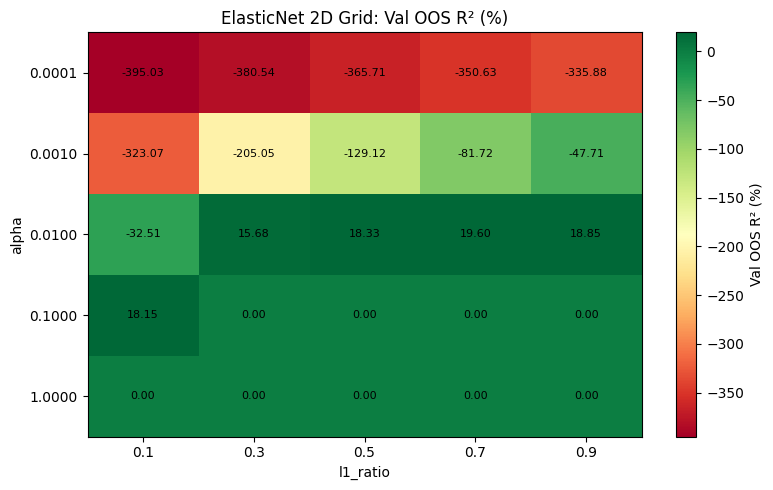

In [6]:
# Heatmap of Val OOS R² over the 2D grid
import itertools

grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in grid_results])
pivot   = grid_df.pivot(index='alpha', columns='l1_ratio', values='oos_r2_val') * 100

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.1f}' for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{v:.4f}' for v in pivot.index])
ax.set_xlabel('l1_ratio')
ax.set_ylabel('alpha')
ax.set_title('ElasticNet 2D Grid: Val OOS R² (%)')

# Annotate cells
for i, j in itertools.product(range(len(pivot.index)), range(len(pivot.columns))):
    ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='Val OOS R² (%)')
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
best_model = best['model']

preds = {
    'train': best_model.predict(X_train),
    'val':   best_model.predict(X_val),
    'test':  best_model.predict(X_test),
}

metrics = evaluate_splits(
    y_train, preds['train'],
    y_val,   preds['val'],
    y_test,  preds['test'],
    train_mean = y_train_mean,
)

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': best_model.coef_})
nonzero_df = coef_df[coef_df['coefficient'] != 0].sort_values('coefficient', key=abs, ascending=False)

print('ELASTICNET — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  Alpha          : {best['alpha']}")
print(f"  l1_ratio       : {best['l1_ratio']}")
print(f"  Non-zero coefs : {best['n_nonzero']} / {len(feature_cols)}")
print(f"  Sparsity       : {(1 - best['n_nonzero']/len(feature_cols))*100:.1f}% zeroed out")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)
print(f"\nTop 10 features (by |coefficient|):")
print(nonzero_df.head(10).to_string(index=False))

ELASTICNET — BEST MODEL EVALUATION
  Alpha          : 0.01
  l1_ratio       : 0.7
  Non-zero coefs : 7 / 209
  Sparsity       : 96.7% zeroed out

  Train R²       : +18.8535%
  Val R²         : +18.1627%
  Test R²        : +17.3781%

  OOS R² Val     : +19.5987%
  OOS R² Test    : +17.8389%

Top 10 features (by |coefficient|):
       feature  coefficient
        High52     0.024169
    ReturnSkew    -0.010045
  ReturnSkew3F    -0.007758
        MaxRet    -0.005113
       Spinoff     0.001888
        IndMom    -0.000703
RIO_Volatility     0.000509


## Step 5 — Portfolio Formation & Sharpe Ratio

ELASTICNET LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 11.5109%
  Std monthly    : 7.7141%
  Sharpe (ann.)  : 5.1691


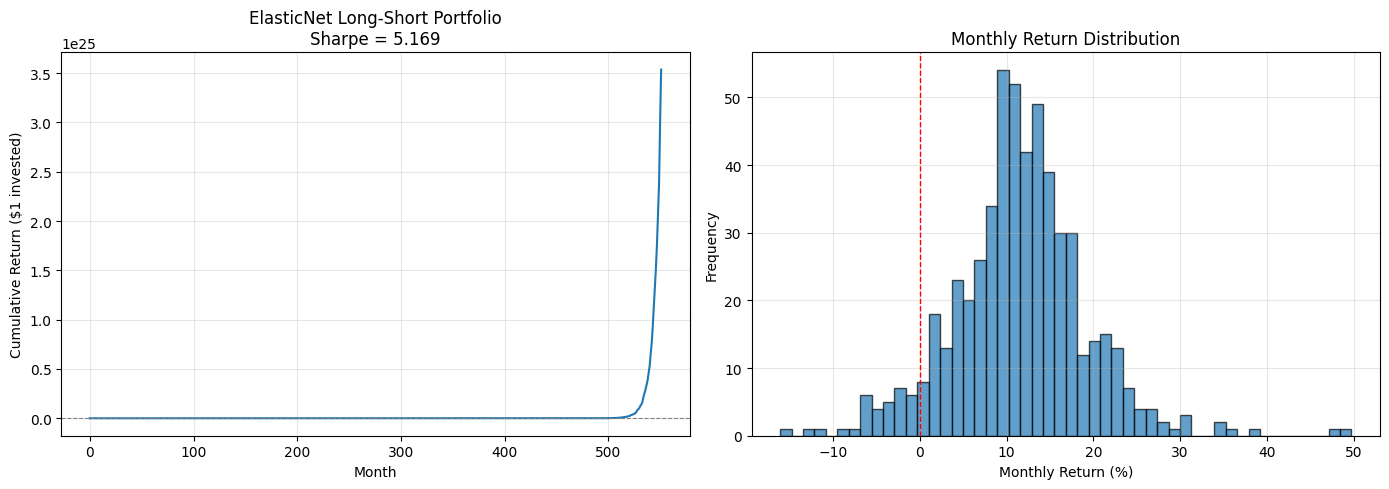

In [8]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base,
    date_col  = CONFIG['DATE_COL'],
    pred_col  = 'predicted_ret',
    ret_col   = 'actual_ret',
    n_deciles = CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('ELASTICNET LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Cumulative Return ($1 invested)')
axes[0].set_title(f'ElasticNet Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)

axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Monthly Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6 — Save Results

In [9]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'Elastic Net',
        description   = 'ElasticNet Regression (L1 + L2 regularization)',
        tuning_params = f"alpha={best['alpha']}, l1_ratio={best['l1_ratio']}, n_nonzero={best['n_nonzero']}",
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'elasticnet',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'elasticnet_summary.csv')
    print(f'Saved: {path}')

    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'elasticnet_portfolios.csv')
    print(f'Saved: {path}')

else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/elasticnet_summary.csv
Saved: results/elasticnet_portfolios.csv
